# Практика: 5 графиков на датасете Iris

**Датасет фиксированный** — `sklearn.load_iris` (150 объектов, 4 признака, 3 вида), загружается офлайн и детерминированно.

**Как работать.** Для каждого графика три ячейки:
1. **задание** (markdown) — что построить;
2. **реализация** — заполните тело функции вместо `# TODO`, функция должна вернуть объект осей (`ax`);
3. **проверка** — запустите её: она отрисует ваш график и напечатает `PASS/FAIL` по каждому критерию (заголовок, подписи осей, **и сами данные графика**). Ячейка проходит, только если все критерии `PASS`.

Требования к оформлению (заголовок, подписи осей, легенда) проверяются автоматически. Графики должны быть аккуратными.

Сначала выполните две ячейки ниже — данные и функция проверки.

In [1]:
%pip install numpy pandas matplotlib scikit-learn

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 246.0 kB/s eta 0:00:001m701.6 kB/s eta 0:00:01
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using ca

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
dfc= df.drop(columns="target")

FEATURES = list(iris.feature_names)      # 4 числовых признака
SPECIES  = list(iris.target_names)       # ['setosa', 'versicolor', 'virginica']
X_COL, Y_COL = FEATURES[0], FEATURES[2]  # 'sepal length (cm)', 'petal length (cm)'
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
from matplotlib.container import BarContainer
import matplotlib.cbook as cbook

def run_checks(title, checks):
    """checks: список (описание, callable->bool). Печатает PASS/FAIL и падает, если не всё пройдено."""
    print(title)
    ok_count = 0
    for desc, cond in checks:
        try:
            ok = bool(cond())
        except Exception as e:
            ok, desc = False, f"{desc}  [ошибка: {type(e).__name__}: {e}]"
        print(f"  [{'PASS' if ok else 'FAIL'}] {desc}")
        ok_count += ok
    print(f"  -> {ok_count}/{len(checks)} проверок пройдено")
    assert ok_count == len(checks), "Не все проверки пройдены — доработайте график."

def _all_offsets(ax):
    offs = [np.asarray(c.get_offsets()) for c in ax.collections if len(c.get_offsets())]
    return np.vstack(offs) if offs else np.empty((0, 2))

### График 1 — диаграмма рассеяния с линейной аппроксимацией
Постройте scatter «длина чашелистика (`X_COL`) — длина лепестка (`Y_COL`)», цвет по виду.
Для **каждого** вида добавьте свою линию регрессии (`np.polyfit`, степень 1).
Оформите: заголовок, подписи осей, легенду, сетку. Функция возвращает `ax`.

In [6]:
import matplotlib.colors as mcolors


def lighten_color(color, amount=0.5):
    r, g, b = mcolors.to_rgb(color)
    return (
        r + (1 - r) * amount,
        g + (1 - g) * amount,
        b + (1 - b) * amount,
    )


def plot_1():
    fig, ax = plt.subplots(figsize=(7, 5))
    # TODO: постройте диаграмму рассеяния для каждого вида: по X — длина чашелистика,
    #       по Y — длина лепестка; каждый вид своим цветом и со своей подписью (label)
    # TODO: для каждого вида добавьте линию линейной регрессии (аппроксимация 1-й степени)
    # TODO: задайте заголовок, подписи осей (с единицами), легенду и включите сетку

    rng = np.random.default_rng(42)
    
    for species, group in df.groupby("species"):
        x, y = group[X_COL], group[Y_COL]
        scatter = ax.scatter(x, y, label=species, s=20)

        random_color = rng.random(3)
        k, b = np.polyfit(x, y, 1)
        xr = np.linspace(min(x), max(x), 100)

        scatter_color = scatter.get_facecolor()[0]
        line_color = lighten_color(scatter_color)
        ax.plot(xr, k * xr + b, color=line_color)
        
    ax.set_xlabel(X_COL)
    ax.set_ylabel(Y_COL)
    ax.set_title("Relationship Between Sepal Length and Petal Length Across Iris Species")
    ax.legend(title="Species")
    ax.grid(True)
    return ax

График 1 — scatter + линейная аппроксимация
  [PASS] Заголовок задан
  [PASS] Подпись оси X задана
  [PASS] Подпись оси Y задана
  [PASS] Легенда из 3 видов
  [PASS] Нанесены все 150 точек
  [PASS] По X отложена длина чашелистика
  [PASS] По Y отложена длина лепестка
  [PASS] 3 линии регрессии по видам
  [PASS] Наклоны линий = polyfit по видам
  [PASS] Сетка включена
  -> 10/10 проверок пройдено


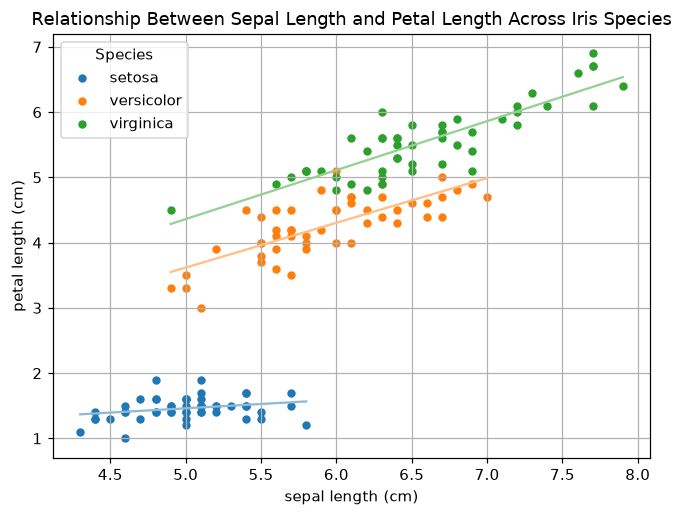

In [7]:
ax = plot_1()

_xy = _all_offsets(ax)
_lines = [l for l in ax.lines if len(l.get_xdata()) >= 2]
_slopes_actual = sorted(
    (l.get_ydata()[-1] - l.get_ydata()[0]) / (l.get_xdata()[-1] - l.get_xdata()[0])
    for l in _lines
)
_slopes_expected = sorted(np.polyfit(g[X_COL], g[Y_COL], 1)[0] for _, g in df.groupby("species"))

run_checks("График 1 — scatter + линейная аппроксимация", [
    ("Заголовок задан",                 lambda: ax.get_title().strip() != ""),
    ("Подпись оси X задана",            lambda: ax.get_xlabel().strip() != ""),
    ("Подпись оси Y задана",            lambda: ax.get_ylabel().strip() != ""),
    ("Легенда из 3 видов",              lambda: len(ax.get_legend().get_texts()) == 3),
    ("Нанесены все 150 точек",          lambda: _xy.shape[0] == 150),
    ("По X отложена длина чашелистика", lambda: np.allclose(np.sort(_xy[:, 0]), np.sort(df[X_COL]))),
    ("По Y отложена длина лепестка",    lambda: np.allclose(np.sort(_xy[:, 1]), np.sort(df[Y_COL]))),
    ("3 линии регрессии по видам",      lambda: len(_lines) == 3),
    ("Наклоны линий = polyfit по видам",lambda: np.allclose(_slopes_actual, _slopes_expected, atol=1e-6)),
    ("Сетка включена",                  lambda: any(g.get_visible() for g in ax.get_xgridlines())),
])



### График 2 — сгруппированные столбцы со средними
Для каждого из 4 признаков постройте столбцы, сгруппированные по видам:
высота — среднее, усы ошибок (`yerr`) — стандартное отклонение.
Подписи оси X — названия признаков, легенда по видам. Функция возвращает `ax`.

In [62]:
def plot_2():
    fig, ax = plt.subplots(figsize=(9, 5))

    species_groups = list(df.groupby("species"))
    species_names = [str(species) for species, _ in species_groups]

    group_width = 0.8
    bar_width = group_width / len(FEATURES)

    all_positions = []
    all_labels = []
    legend_artists = []

    for species_index, (species, group) in enumerate(species_groups):
        means = [group[column].mean() for column in FEATURES]
        standard_deviations = [group[column].std() for column in FEATURES]

        column_offsets = (
            np.arange(len(FEATURES)) * bar_width
            - group_width / 2
            + bar_width / 2
        )

        position = species_index + column_offsets

        bars = ax.bar(
            position,
            means,
            width=bar_width,
            yerr=standard_deviations,
            capsize=3,
        )

        legend_artists.append(bars)
        all_positions.extend(position)
        all_labels.extend(FEATURES)

    ticks_with_labels = sorted(zip(all_positions, all_labels))
    tick_positions, tick_labels = zip(*ticks_with_labels)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=70, ha="center", fontsize=7)

    ax.set_ylabel("Mean value")
    ax.set_title("Relationship between iris mean values grouped by species")
    ax.legend(title="Species", labels=species_names, handles=legend_artists)
    fig.tight_layout()
    return ax

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')
График 2 — сгруппированные столбцы со средними
  [PASS] 3 группы столбцов (по видам)
  [PASS] В каждой группе 4 столбца
  [PASS] Высоты столбцов = средние по видам
  [PASS] У всех групп есть усы ошибок
  [PASS] Подписи X = названия признаков
  [PASS] Легенда из 3 видов
  [PASS] Подпись оси Y задана
  [PASS] Заголовок задан
  -> 8/8 проверок пройдено


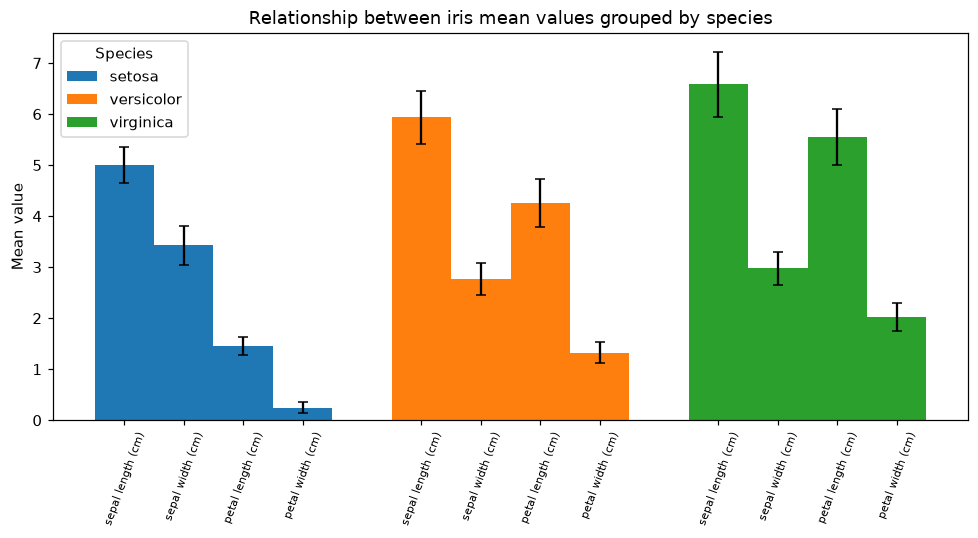

In [63]:
ax = plot_2()

_bars = [c for c in ax.containers if isinstance(c, BarContainer)]
_means = df.groupby("species")[FEATURES].mean()
_expected = sorted(tuple(np.round(_means.loc[s].values, 6)) for s in SPECIES)
_actual = sorted(tuple(np.round([b.get_height() for b in c], 6)) for c in _bars)
_xt = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]

run_checks("График 2 — сгруппированные столбцы со средними", [
    ("3 группы столбцов (по видам)",    lambda: len(_bars) == 3),
    ("В каждой группе 4 столбца",       lambda: all(len(c) == 4 for c in _bars)),
    ("Высоты столбцов = средние по видам", lambda: _actual == _expected),
    ("У всех групп есть усы ошибок",    lambda: all(c.errorbar is not None for c in _bars)),
    ("Подписи X = названия признаков",  lambda: set(_xt) == set(FEATURES)),
    ("Легенда из 3 видов",              lambda: len(ax.get_legend().get_texts()) == 3),
    ("Подпись оси Y задана",            lambda: ax.get_ylabel().strip() != ""),
    ("Заголовок задан",                 lambda: ax.get_title().strip() != ""),
])

### График 3 — тепловая карта корреляций
Постройте heatmap матрицы корреляций 4 признаков через `ax.imshow` (шкала −1..1, `cmap` на выбор).
Аннотируйте каждую ячейку значением с 2 знаками, добавьте colorbar и подписи осей (названия признаков).
Функция возвращает `ax`.

In [ ]:
def plot_3():
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    # TODO: посчитайте матрицу корреляций 4 признаков и покажите её как изображение (шкала от -1 до 1)
    # TODO: подпишите деления обеих осей названиями признаков
    # TODO: в каждой ячейке подпишите значение корреляции с 2 знаками после запятой
    # TODO: добавьте colorbar и заголовок


    numeric_columns = df.select_dtypes(include="number").columns
    corr_matrix = df[numeric_columns].corr()
    im = ax.imshow(corr_matrix.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)

    
    for i in range(len(numeric_columns)):
        for j in range(len(numeric_columns)):
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")


    ax.set_xticks(range(len(numeric_columns)))
    ax.set_yticks(range(len(numeric_columns)))
    ax.set_xticklabels(numeric_columns, rotation=45, ha='right')
    ax.set_yticklabels(numeric_columns)
    ax.set_title("Matrix correlation between iris numeric values")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    return ax

In [ ]:
ax = plot_3()

_corr = np.corrcoef(df[FEATURES].values, rowvar=False)
_img = ax.images[0] if ax.images else None
_txt_vals = sorted(round(float(t.get_text()), 2) for t in ax.texts)
_expected_vals = sorted(round(float(v), 2) for v in _corr.ravel())
_xt = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]
_yt = [t.get_text() for t in ax.get_yticklabels() if t.get_text()]

run_checks("График 3 — тепловая карта корреляций", [
    ("Есть изображение (imshow)",        lambda: _img is not None),
    ("Данные = матрица корреляций",      lambda: np.allclose(np.asarray(_img.get_array()), _corr)),
    ("Пределы шкалы -1..1",              lambda: np.allclose(_img.get_clim(), (-1, 1))),
    ("Colorbar добавлен",                lambda: _img.colorbar is not None),
    ("16 аннотаций со значениями",       lambda: len(ax.texts) == 16),
    ("Значения аннотаций = корреляции",  lambda: _txt_vals == _expected_vals),
    ("Подписи X = признаки",             lambda: set(_xt) == set(FEATURES)),
    ("Подписи Y = признаки",             lambda: set(_yt) == set(FEATURES)),
    ("Заголовок задан",                  lambda: ax.get_title().strip() != ""),
])

### График 4 — box plot с наложением точек
Для длины лепестка по видам постройте box plot с `patch_artist=True` и **разными цветами** коробок,
затем наложите джиттер-точки всех 150 наблюдений (небольшой случайный сдвиг по X).
Подписи оси X — виды. Функция возвращает `ax`.

In [ ]:
import matplotlib as mpl


def plot_4():
    fig, ax = plt.subplots(figsize=(7.5, 5))
    # TODO: постройте box plot длины лепестка по трём видам (с заливкой коробок),
    #       каждую коробку — своим цветом
    # TODO: поверх наложите все наблюдения точками с небольшим случайным сдвигом по X
    #       (джиттер) и прозрачностью
    # TODO: подпишите деления оси X названиями видов, добавьте подпись оси Y и заголовок

    species_list = df["species"].unique()
    grouped = df.groupby("species")["petal length (cm)"].apply(list)
    bp = ax.boxplot(grouped, tick_labels=species_list, patch_artist=True, widths=0.5)

    cmap = mpl.colormaps["tab10"]
    colors = [cmap(i) for i in range(len(species_list))]

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    lengths = [df[df["species"] == sp]["petal length (cm)"] for sp in species_list]
    for i, values in enumerate(lengths, start=1):
        jitter = np.random.normal(i, 0.06, size=len(values))
        ax.scatter(jitter, values, s=12, alpha=0.6, color='black', zorder=3)

    ax.set_ylabel("petal lenght (cm)")
    ax.set_title("Petal lenght (cm) by species")
    fig.tight_layout()
    return ax

In [ ]:
ax = plot_4()

_stats = {s: cbook.boxplot_stats(df.loc[df.species == s, Y_COL].values)[0] for s in SPECIES}
_expected_box = sorted((round(v["q1"], 6), round(v["q3"], 6)) for v in _stats.values())
_box_ranges = sorted(
    (round(float(p.get_path().vertices[:, 1].min()), 6),
     round(float(p.get_path().vertices[:, 1].max()), 6))
    for p in ax.patches
)
_xy = _all_offsets(ax)
_facecolors = {tuple(np.round(p.get_facecolor(), 3)) for p in ax.patches}
_xt = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]

run_checks("График 4 — box plot + наложение точек", [
    ("3 коробки (patch_artist)",          lambda: len(ax.patches) == 3),
    ("Коробки разного цвета",             lambda: len(_facecolors) == 3),
    ("Границы коробок = квартили Q1..Q3", lambda: _box_ranges == _expected_box),
    ("Наложены все 150 точек",            lambda: _xy.shape[0] == 150),
    ("Y точек = длина лепестка",          lambda: np.allclose(np.sort(_xy[:, 1]), np.sort(df[Y_COL]))),
    ("Подписи X = виды",                  lambda: set(_xt) == set(SPECIES)),
    ("Подпись оси Y задана",              lambda: ax.get_ylabel().strip() != ""),
    ("Заголовок задан",                   lambda: ax.get_title().strip() != ""),
])

### График 5 — гистограмма и ECDF на двух осях
На основной оси — гистограмма длины лепестка (`bins=20`, частоты).
На второй оси (`ax1.twinx()`) — ECDF: `x = np.sort(значения)`, `y = np.arange(1, n+1)/n`.
Две подписи оси Y (слева/справа), подпись оси X, заголовок. Функция возвращает кортеж `(ax_hist, ax_ecdf)`.

In [ ]:
def plot_5():
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()   # вторая ось Y с общей осью X
    # TODO: на ax1 постройте гистограмму длины лепестка (20 столбцов, частоты);
    #       подпишите ось X и левую ось Y

    ax1.hist(df["petal length (cm)"], bins=20)
    # TODO: на ax2 постройте ECDF: по X — отсортированные значения, по Y — накопленная
    #       доля (1..n)/n; подпишите правую ось Y
    # TODO: добавьте заголовок (по желанию — общую легенду для обеих осей)
    x = np.sort(df["petal length (cm)"])
    n = len(x)
    y = np.arange(1, n + 1) / n
    ax2.plot(x, y, color="crimson")

    ax1.set_xlabel("petal lenght (cm)")
    ax1.set_ylabel("Frequency")
    ax2.set_ylabel("Cumulative proportion")

    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="crimson")

    fig.suptitle("Histogram and ECDF of petal length (cm)")
    fig.tight_layout()
    return ax1, ax2

In [ ]:
ax1, ax2 = plot_5()
_pl = df[Y_COL].values

def _ecdf_line():
    cand = sorted((l for l in ax2.lines if len(l.get_ydata()) >= 5), key=lambda l: len(l.get_ydata()))
    assert cand, "на второй оси нет линии ECDF"
    return cand[-1]

run_checks("График 5 — гистограмма + ECDF на двух осях", [
    ("Вторая ось — twin от первой (общий bbox)",
        lambda: np.allclose(ax1.get_position().bounds, ax2.get_position().bounds)),
    ("Гистограмма из 20 столбцов",       lambda: len(ax1.patches) == 20),
    ("Сумма частот = 150",               lambda: abs(sum(p.get_height() for p in ax1.patches) - 150) < 1e-6),
    ("ECDF монотонно не убывает",        lambda: bool(np.all(np.diff(_ecdf_line().get_ydata()) >= -1e-9))),
    ("ECDF заканчивается на 1.0",        lambda: abs(np.max(_ecdf_line().get_ydata()) - 1.0) < 1e-6),
    ("ECDF построена по длине лепестка", lambda: np.allclose(np.sort(_ecdf_line().get_xdata()), np.sort(_pl))),
    ("Левая подпись оси Y задана",       lambda: ax1.get_ylabel().strip() != ""),
    ("Правая подпись оси Y задана",      lambda: ax2.get_ylabel().strip() != ""),
    ("Подпись оси X задана",             lambda: ax1.get_xlabel().strip() != ""),
])